# 03 - Analisis de combinaciones de componentes

Este notebook esta reservado para el analisis final del enfoque de combinaciones de componentes.

Preguntas posibles:
- que combinaciones aparecen con mayor frecuencia;
- que componentes suelen coexistir;
- que patrones relevantes emergen en el dataset.

In [10]:
# Celda 1 — imports
from pathlib import Path
import sys
import pandas as pd

project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.enfoque_01_combinaciones_componentes.analysis import (
    plot_top_pares,
    plot_top_componentes,
    plot_heatmap_coocurrencia,
    plot_efectos_secundarios_por_tamanio,
    plot_network_graph,
    plot_histograma_componentes,
    plot_scatter_valoracion,
)
from src.enfoque_01_combinaciones_componentes.cleaning import CATEGORIAS_TAMAÑO_ORDER

df_clean = pd.read_csv(project_root / "data/processed/medicine_cleaned.csv")
df_exploded = pd.read_csv(project_root / "data/processed/medicine_exploded.csv")
df_pairs = pd.read_csv(project_root / "data/processed/medicine_pairs.csv")
cooc_matrix = pd.read_csv(project_root / "data/processed/cooc_matrix.csv", index_col=0)

df_clean["size_category"] = pd.Categorical(
    df_clean["size_category"],
    categories=CATEGORIAS_TAMAÑO_ORDER,
    ordered=True
)

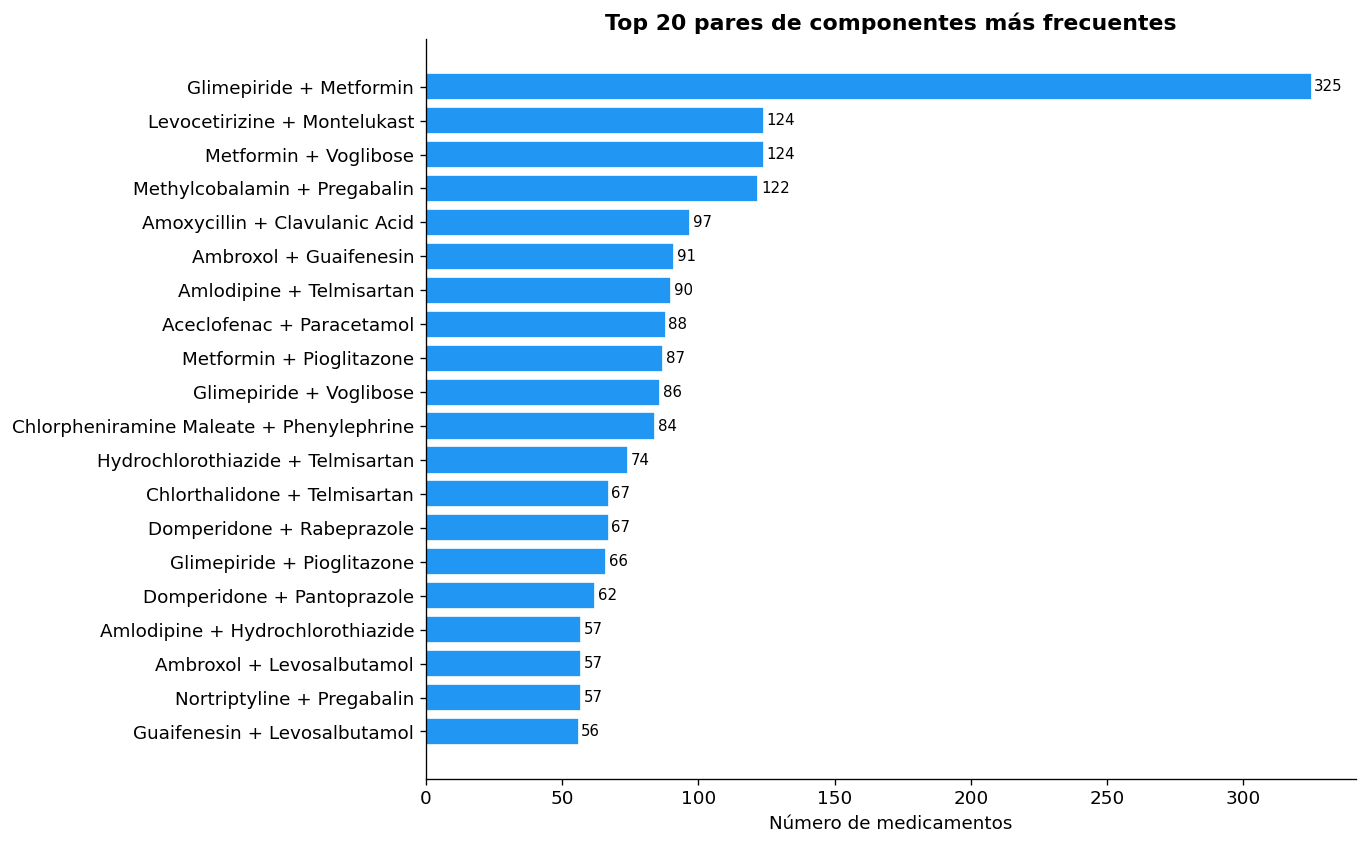

[analysis] Figura guardada: /home/lucasmoncada/SCY1101-Exp1-Drug-Data-Analysis/outputs/figures/top_pares_componentes.png
[analysis] Tabla guardada: /home/lucasmoncada/SCY1101-Exp1-Drug-Data-Analysis/outputs/tables/top_pares_componentes.csv


,par,frecuencia
0,Glimepiride + Metformin,325
1,Levocetirizine + Montelukast,124
2,Metformin + Voglibose,124
3,Methylcobalamin + Pregabalin,122
4,Amoxycillin + Clavulanic Acid,97
5,Ambroxol + Guaifenesin,91
6,Amlodipine + Telmisartan,90
7,Aceclofenac + Paracetamol,88
8,Metformin + Pioglitazone,87
9,Glimepiride + Voglibose,86


In [11]:
# Celda 2 — Gráfico 1
plot_top_pares(df_pairs, top_n=20)

## Interpretación — Top 20 pares de componentes

- Aca podemos observar el podio, combiaciones como **Glimepiride + Metformin** tienen mucho sentido, ya que ambos componentes se usan mucho para el tratamiento de la diabetes tipo 2.

De hecho gracias a esto podemos revelar patrones medicos muy claros sobre las condiciones que mas requieren terapias combinadas.

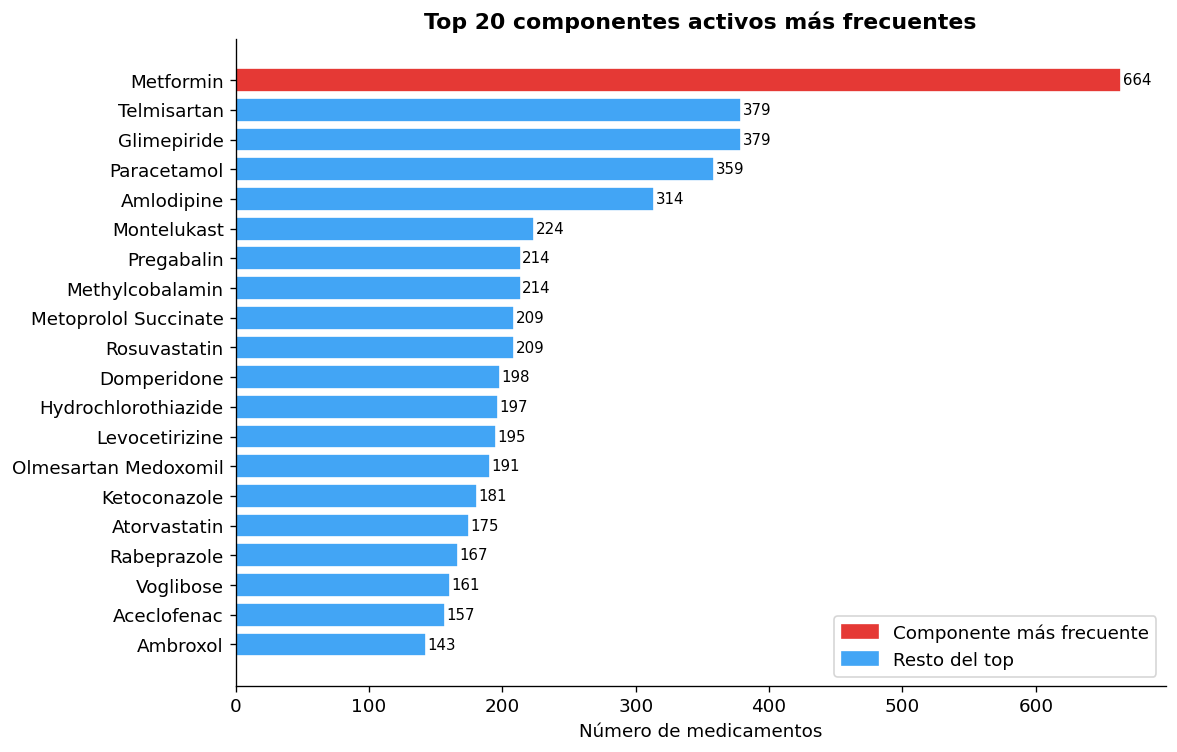

[analysis] Figura guardada: /home/lucasmoncada/SCY1101-Exp1-Drug-Data-Analysis/outputs/figures/top_componentes_individuales.png
[analysis] Tabla guardada: /home/lucasmoncada/SCY1101-Exp1-Drug-Data-Analysis/outputs/tables/top_componentes_individuales.csv


,component,frecuencia
0,Metformin,664
1,Telmisartan,379
2,Glimepiride,379
3,Paracetamol,359
4,Amlodipine,314
5,Montelukast,224
6,Pregabalin,214
7,Methylcobalamin,214
8,Metoprolol Succinate,209
9,Rosuvastatin,209


In [12]:
# Celda 3 — Gráfico 2
plot_top_componentes(df_exploded, top_n=20)

## Interpretación — Top 20 componentes individuales
- Aca tenemos el peso más grande, que seria la Metformina con 664 apariciones, duplicando el segundo lugar. Podemos incluso concluir y demostrar que es el ancla para muchas combinaciones (Glimepirida, Voglibose, Pioglitazona). Si hay un medicamento para la diabetes, es altamente probable que contenga Metformina

- Y así como la diabetes esta dominando, la hipertension y control del colesterol le siguen.

- Como omnipresente estaría el paracetamol con 359 apariciones y se consolida como el analgesico base universal, de hecho tiene mucho sentido porque se combina mucho con relajantes musculares o antiinflamatorios (que tambien esta en el top)

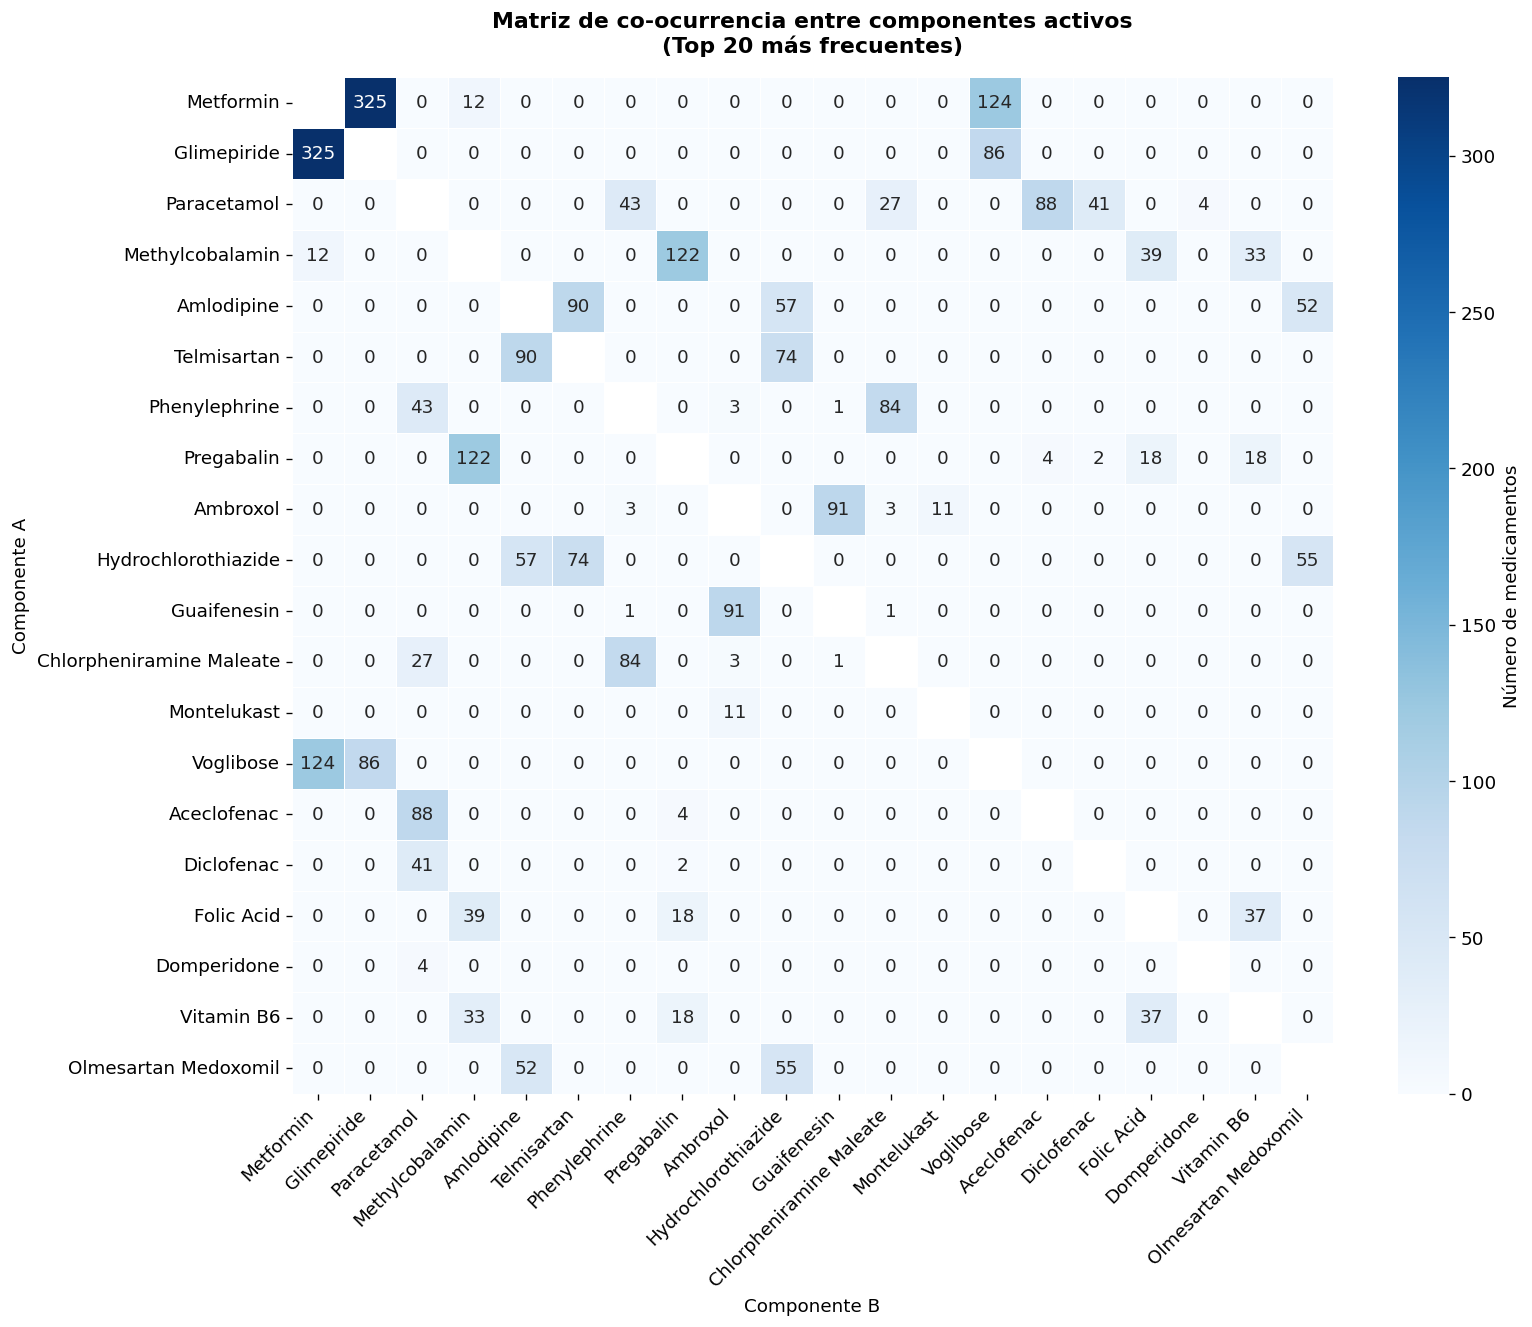

[analysis] Figura guardada: /home/lucasmoncada/SCY1101-Exp1-Drug-Data-Analysis/outputs/figures/heatmap_coocurrencia.png


In [13]:
plot_heatmap_coocurrencia(cooc_matrix)

## Interpretación — Heatmap de co-ocurrencia

La matriz nos muestra que **Glimepiride + Metformin** es el par que tiene mayor co-ocurrencia del datasets con un numero de 325 medicamentos, luego le sigue **Metformin + Voglibose** y **Levocetirizine + Montelukast** 124 cada uno.

Se pueden observar dos clusters principales, los cuales son:
- **Antidiabeticos**: Metformina, Glimepiride y Voglibose forman un triangulo de alta co-ocurrencia, eso nos demuestra de un uso frecuente de terapias combinadas para diabetes de tipo 3.
- **Antihipertensivos**: Amlodipine, Telmisartan e Hydrochlorothiazide, estos también aparecen de forma frecuente para el control de presion arterial.

Un analisis por encima podría ser que se pueden ver varias celdas con el valor de 0, lo que nos indica que el dataset tiene combinaciones altamente especializadas para areas terapeuticas.

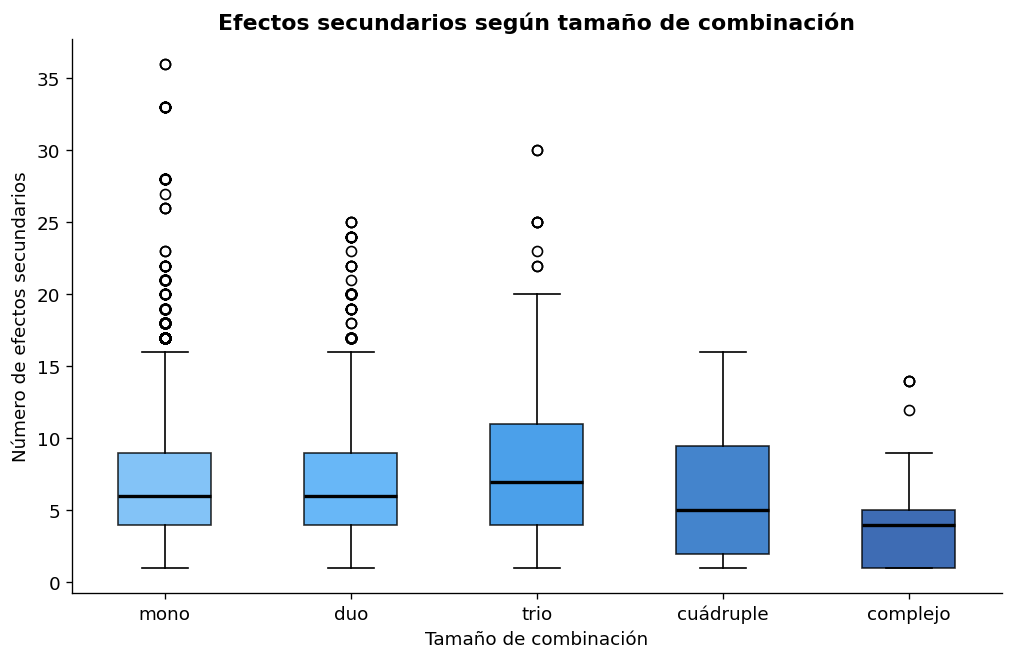

[analysis] Figura guardada: /home/lucasmoncada/SCY1101-Exp1-Drug-Data-Analysis/outputs/figures/boxplot_efectos_secundarios.png


In [14]:
plot_efectos_secundarios_por_tamanio(df_clean)

## Interpretación — Efectos secundarios según tamaño de combinación

Al contrario de la hipotesis inicial, los medicamentos **complejos** (+5 componentes) tienen una mediana de efectos secundarios menor (~4) que los monocomponentes (~6) y los trios (~7).

Una explicación podría ser que las fomrulaciones con muchos componentes son altamente especializadas y apuntan a condiciones especificas, mientras que los que son monocomponentes incluyen farmacos que son de amplio espectro con perfiles de efectos mas extensos.

Lo que podemos observar es que los tríos tienen la mayor varianza, esto demuestra que hay una mayor heterogenidad en el grupo. Son incluso observables los outliers en mono y duo (con hasta 36 efectos) corresponden a medicamentos con perfiles de seguridad 
particularmente complejos.

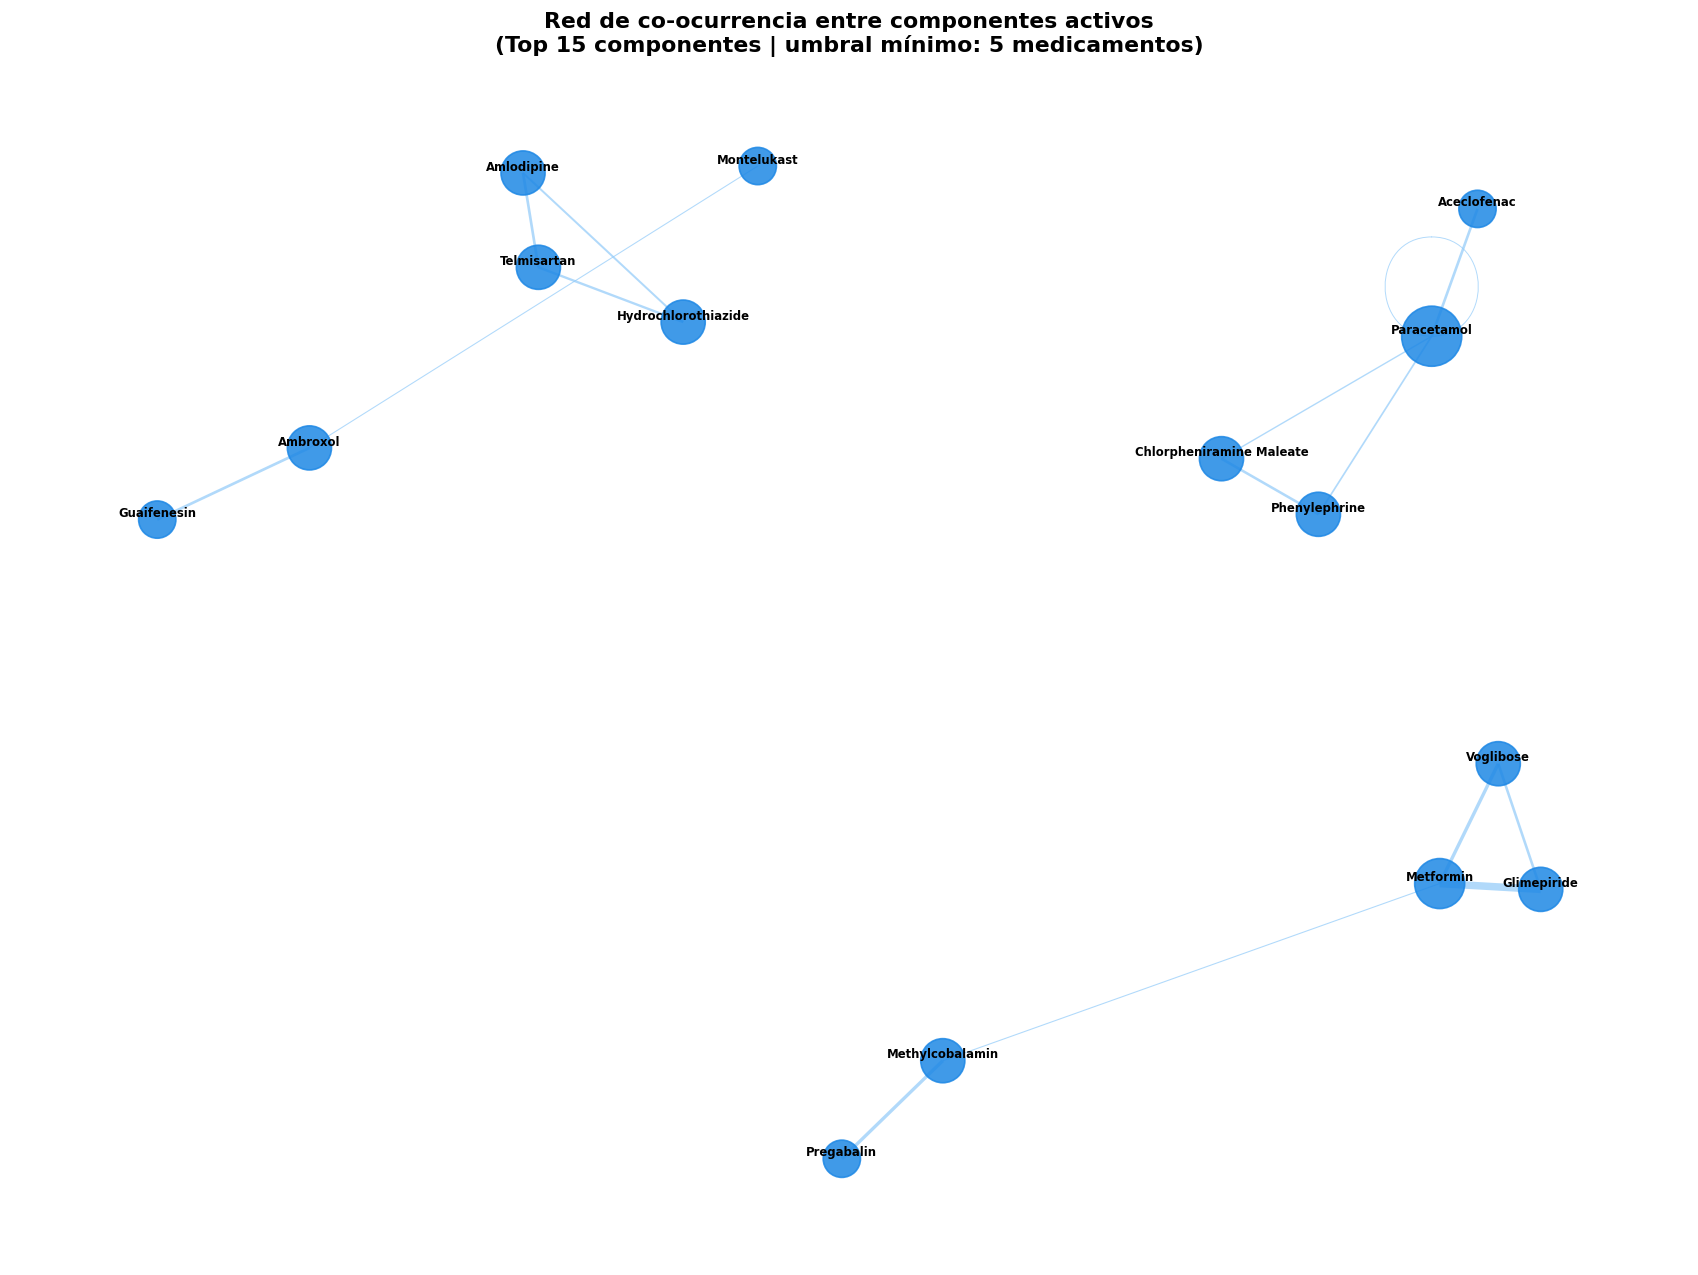

[analysis] Figura guardada: /home/lucasmoncada/SCY1101-Exp1-Drug-Data-Analysis/outputs/figures/network_graph_coocurrencia.png


In [15]:
plot_network_graph(df_pairs, top_n_componentes=15, min_frecuencia=5)

## Interpretación — Red de co-ocurrencia

El grafo nos revela que hay **tres cluesteres** claramente separados.

Tenemos:
- **Cluster Antidiabetico** (el del inferior derecho): con Metformina como nodo principal o base de mayor grado.
- **Cluster antihipertensivo** (Superior izquierdo): con Telmisartan, 
  Amlodipine e Hydrochlorothiazide conectados entre sí.
- **Cluster respiratorio/analgesico** (superior derecho): con Paracetamol, 
  Phenylephrine y Chlorpheniramine Maleate.

Que indica la separacion?
- La separacion de los clusteres indica que los componentes rara vez cruzan areas terapeuticas, eso lo hace consistente con la practica clinica. La Metformina es el componente mas destacado en el dataset. 

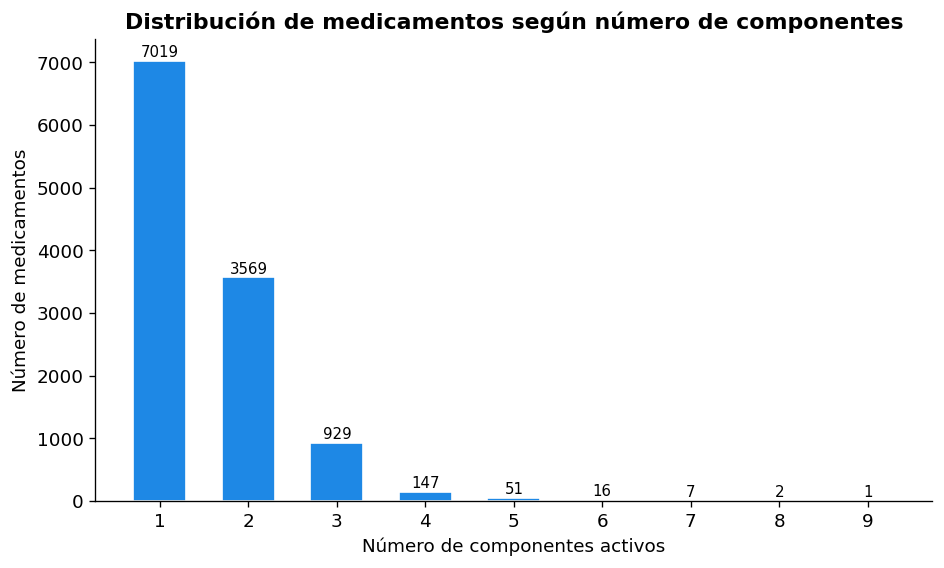

[analysis] Figura guardada: /home/lucasmoncada/SCY1101-Exp1-Drug-Data-Analysis/outputs/figures/histograma_n_componentes.png


In [16]:
plot_histograma_componentes(df_clean)

## Interpretación — Distribución según número de componentes

El dataset presenta una distribución de **cola larga hacia la derecha**:
- **Monocomponentes**: 7.019 medicamentos (59.8%) — dominan el mercado.
- **Dúos**: 3.569 medicamentos (30.4%) — segundo grupo más relevante.
- **Tríos**: 929 medicamentos (7.9%) — reducción significativa.
- **4+ componentes**: 224 medicamentos (1.9%) — casos minoritarios.

Esta distribución justifica el foco del análisis en combinaciones de 
2 y 3 componentes, ya que representan el 38.3% del dataset y tienen 
suficiente volumen para extraer patrones estadísticamente relevantes.

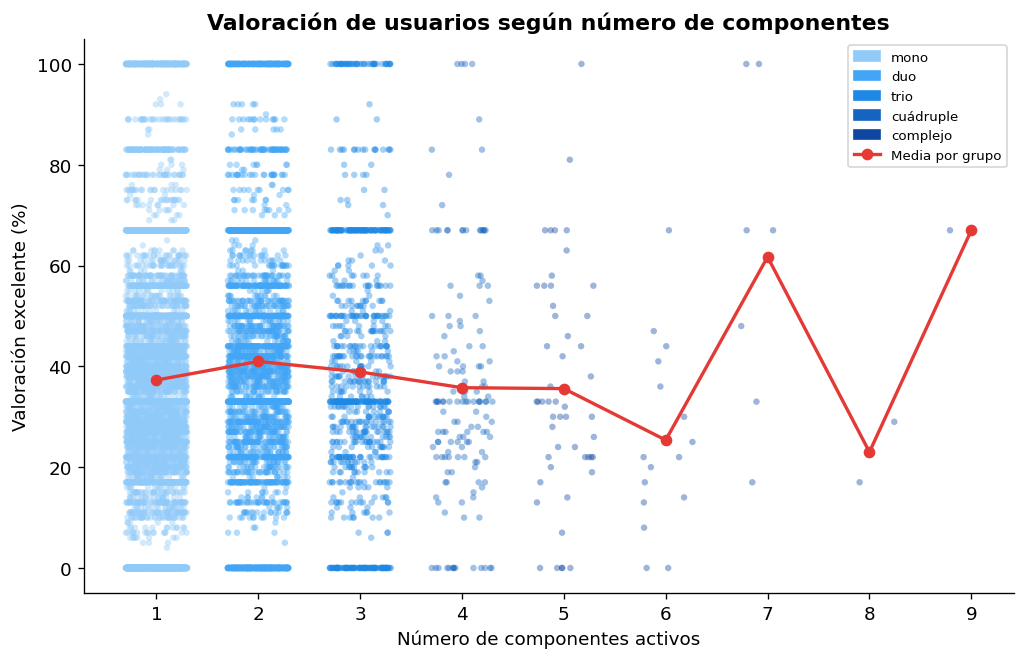

[analysis] Figura guardada: /home/lucasmoncada/SCY1101-Exp1-Drug-Data-Analysis/outputs/figures/scatter_valoracion_componentes.png


In [17]:
plot_scatter_valoracion(df_clean)

## Interpretación — Valoración según número de componentes

La línea de media muestra una **tendencia decreciente** entre 1 y 6 
componentes: los dúos tienen la mejor valoración promedio (~41%) 
mientras que los medicamentos con 6 componentes la tienen más baja (~25%).

Los valores en 7, 8 y 9 componentes no son estadísticamente 
representativos dado su bajo número de medicamentos (7, 2 y 1 
respectivamente), por lo que la alta varianza en esos puntos 
no refleja un patrón real.

Una hipótesis es que los medicamentos más simples tienen indicaciones 
más claras y predecibles para el paciente, mientras que las 
combinaciones complejas pueden generar mayor variabilidad en la 
experiencia clínica.